=== Task 1: Dataset Understanding ===
Number of training images: 60000, Image size: 28x28
Number of testing images: 10000, Image size: 28x28
Number of training labels: 60000
Input features: 28x28 pixel grayscale values (0-255)
Target variable: Integers from 0 to 9, representing 10 clothing categories


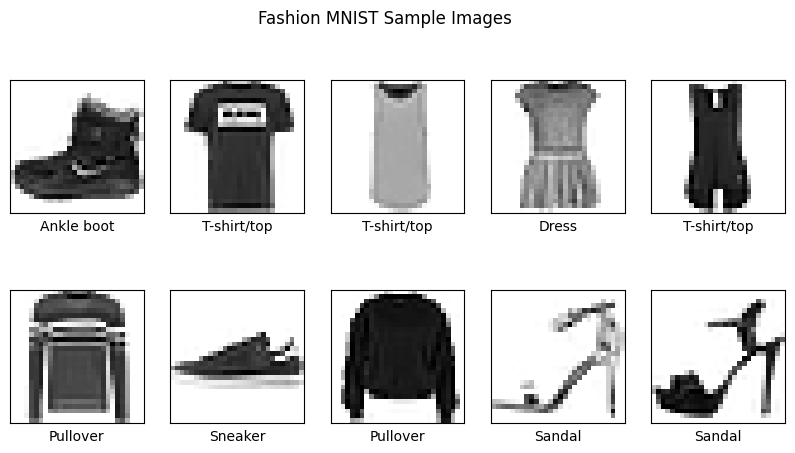

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

# 1. Load the Fashion MNIST dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Create a mapping table for class labels (10 classes in Fashion MNIST)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 2. Dataset Understanding: Output data dimensions and basic information
print("=== Task 1: Dataset Understanding ===")
print(f"Number of training images: {X_train.shape[0]}, Image size: {X_train.shape[1]}x{X_train.shape[2]}")
print(f"Number of testing images: {X_test.shape[0]}, Image size: {X_test.shape[1]}x{X_test.shape[2]}")
print(f"Number of training labels: {len(y_train)}")
print(f"Input features: {X_train.shape[1]}x{X_train.shape[2]} pixel grayscale values (0-255)")
print(f"Target variable: Integers from 0 to 9, representing 10 clothing categories")

# 3. Visualize the first few sample images
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.suptitle("Fashion MNIST Sample Images")
plt.show()

In [3]:
# === Task 2: Data Preprocessing ===

# 1. Normalization
# Scale pixel values from 0~255 to 0~1, which is crucial for the convergence of neural networks (CNN/D2NN)
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

print("Data normalization complete: value range scaled to 0.0 ~ 1.0")

# 2. Reshaping data to fit different models

# [Model A] For Random Forest (Needs to flatten 28x28 into a 1D array of 784)
X_train_rf = X_train_norm.reshape((X_train_norm.shape[0], 28 * 28))
X_test_rf = X_test_norm.reshape((X_test_norm.shape[0], 28 * 28))
print(f"Random Forest training data shape: {X_train_rf.shape}")

# [Model B & C] For CNN and the subsequent D2NN (Needs to add a Channel dimension to become 28x28x1)
# The parameter -1 means automatically inferring the number of samples
X_train_cnn = X_train_norm.reshape((-1, 28, 28, 1))
X_test_cnn = X_test_norm.reshape((-1, 28, 28, 1))

print(f"CNN / D2NN training data shape: {X_train_cnn.shape}")

# Note: We did not specifically handle Missing values or Duplicates here,
# because the official standard Fashion MNIST dataset is already clean and complete.
# You can mention in the Task 2 report: "Due to the use of a standard open-source dataset, it was checked and found to have no missing or duplicate values."

Data normalization complete: value range scaled to 0.0 ~ 1.0
Random Forest training data shape: (60000, 784)
CNN / D2NN training data shape: (60000, 28, 28, 1)


In [5]:
# === Task 3: Model Development (Random Forest) ===
from sklearn.ensemble import RandomForestClassifier
import time

print("Initializing the Random Forest model...")
# n_estimators=100 means we build 100 decision trees, n_jobs=-1 means using all CPU cores to accelerate computation
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Starting to train the Random Forest model (this will take about 1~3 minutes, please be patient)...")
start_time = time.time()

# Model training (Fitting)
rf_model.fit(X_train_rf, y_train)

end_time = time.time()
print(f"Training complete! Total time elapsed: {end_time - start_time:.2f} seconds")

Initializing the Random Forest model...
Starting to train the Random Forest model (this will take about 1~3 minutes, please be patient)...
Training complete! Total time elapsed: 12.53 seconds


Starting model prediction and evaluation...

--- Random Forest Evaluation Results ---
Accuracy:  0.8764
Precision: 0.8753
Recall:    0.8764
F1-score:  0.8749
----------------------------------------


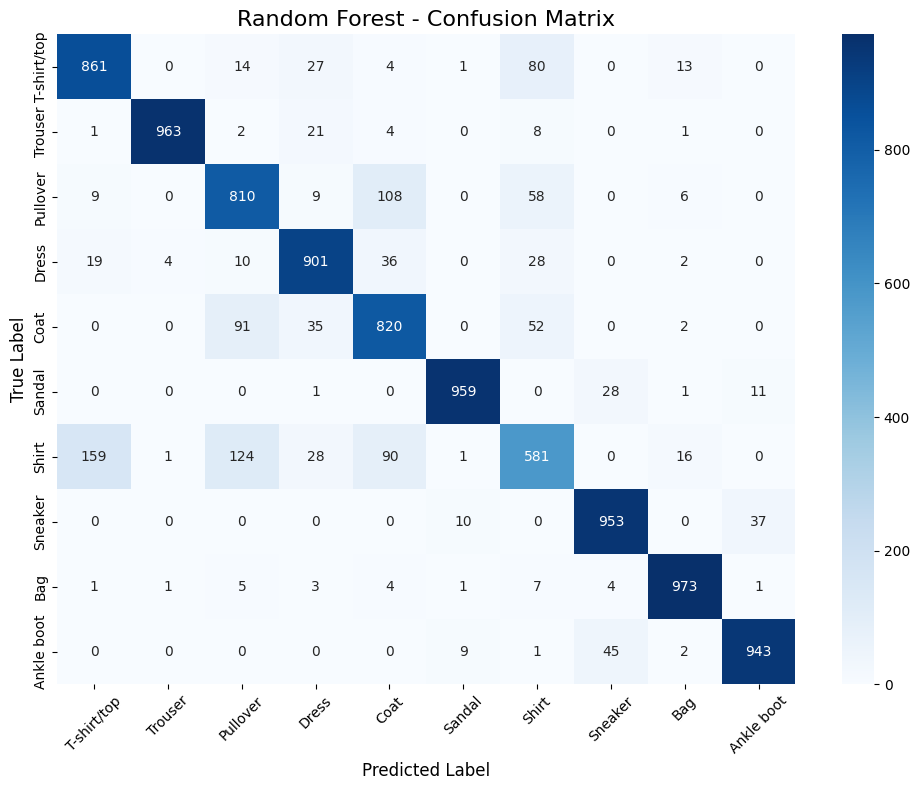

In [6]:
# === Task 4: Model Evaluation (Random Forest) ===
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Starting model prediction and evaluation...")
# Predict using the testing set
y_pred_rf = rf_model.predict(X_test_rf)

# 1. Calculate various metrics
# Because it's a multi-class problem, average='macro' calculates the unweighted mean per label (ignoring class imbalance)
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average='macro')
rec_rf = recall_score(y_test, y_pred_rf, average='macro')
f1_rf = f1_score(y_test, y_pred_rf, average='macro')

print("\n--- Random Forest Evaluation Results ---")
print(f"Accuracy:  {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall:    {rec_rf:.4f}")
print(f"F1-score:  {f1_rf:.4f}")
print("----------------------------------------")

# 2. Plot Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10, 8))
# Plot the heatmap
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Random Forest - Confusion Matrix', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
import tensorflow as tf
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    for device in physical_devices:
        print(f"GPU detected: {device.name}")

GPU detected: /physical_device:GPU:0
GPU detected: /physical_device:GPU:1


In [8]:
# === Task 3: Model Development (CNN) ===
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import time
import tensorflow as tf
import numpy as np

print("Building CNN model architecture...")

tf.random.set_seed(42)
np.random.seed(42)
# Build sequential model
cnn_model = Sequential([
    # First convolution and pooling layer: responsible for extracting basic edges and textures (Input dimension 28x28x1)
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    
    # Second convolution and pooling layer: responsible for extracting more complex shape features
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Flatten layer: converts 2D feature maps to 1D, preparing for fully connected layers
    Flatten(),
    
    # Fully connected layer and Dropout (to prevent overfitting)
    Dense(128, activation='relu'),
    Dropout(0.5), # Randomly drops 50% of neurons to increase generalization ability
    
    # Output layer: 10 nodes corresponding to 10 clothing categories, using softmax to output probabilities
    Dense(10, activation='softmax')
])

# Compile the model
cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Print model architecture (this can also be screenshotted for the Model structure section in the Task 3 report)
cnn_model.summary()

print("\nStarting to train the CNN model...")
start_time = time.time()

# Set up Early Stopping: if validation accuracy doesn't improve for 3 consecutive epochs, stop training early
early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

# Train the model (epochs=10 means training for a maximum of 10 rounds, validation_split=0.2 means using 20% of training data as a validation set)
history_cnn = cnn_model.fit(X_train_cnn, y_train, 
                            epochs=10, 
                            batch_size=64,
                            validation_split=0.2,
                            callbacks=[early_stop])

end_time = time.time()
print(f"CNN training complete! Total time elapsed: {end_time - start_time:.2f} seconds")

Building CNN model architecture...
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 13, 13, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 5, 5, 64)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 1600)              0         
                                                                 
 dense (Dense)       

Starting CNN model prediction and evaluation...
313/313 [==============================] - 1s 3ms/step

=== CNN Evaluation Results ===
Accuracy:  0.9063
Precision: 0.9059
Recall:    0.9063
F1-score:  0.9055


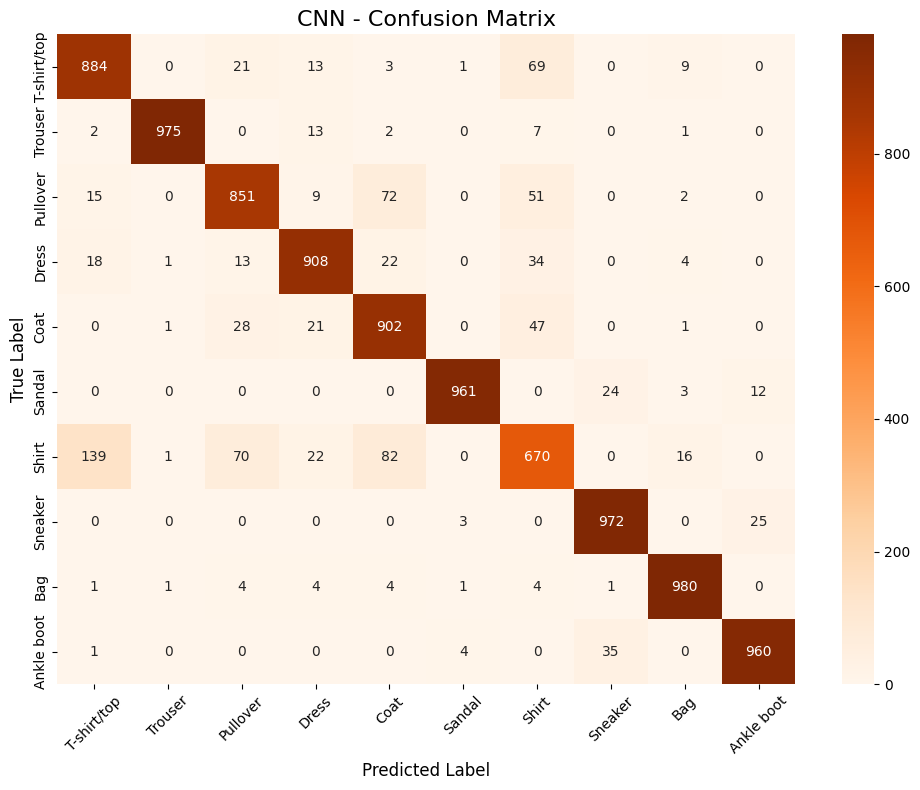

In [9]:
# === Task 4: Model Evaluation (CNN) ===
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Starting CNN model prediction and evaluation...")

# 1. Get prediction results
# CNN outputs a probability distribution across 10 classes (dimension: 10000 x 10)
y_pred_probs_cnn = cnn_model.predict(X_test_cnn)

# Use np.argmax along axis=1 to find the index of the class with the highest probability for each prediction (becomes a 1D array of dimension: 10000)
y_pred_cnn = np.argmax(y_pred_probs_cnn, axis=1)

# 2. Calculate various evaluation metrics
acc_cnn = accuracy_score(y_test, y_pred_cnn)
prec_cnn = precision_score(y_test, y_pred_cnn, average='macro')
rec_cnn = recall_score(y_test, y_pred_cnn, average='macro')
f1_cnn = f1_score(y_test, y_pred_cnn, average='macro')

print("\n=== CNN Evaluation Results ===")
print(f"Accuracy:  {acc_cnn:.4f}")
print(f"Precision: {prec_cnn:.4f}")
print(f"Recall:    {rec_cnn:.4f}")
print(f"F1-score:  {f1_cnn:.4f}")
print("==============================")

# 3. Plot Confusion Matrix
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

plt.figure(figsize=(10, 8))
# Deliberately changing cmap to 'Oranges' here, so it contrasts clearly with the blue of the Random Forest in the report
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('CNN - Confusion Matrix', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# === Task 3: Model Development (D2NN Optical Neural Network) ===
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import time

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU enabled: {[g.name for g in gpus]}")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU detected, running on CPU.")

print("Building D2NN model...")

WAVELENGTH = 0.5e-6   # Wavelength: 500 nm (visible green light)
PIXEL_SIZE = 8e-6     # Pixel pitch: 8 um (matches 28x28 field)
PROP_DIST  = 0.03     # Propagation distance between layers: 3 cm
NUM_LAYERS = 5        # Number of diffractive layers (5, as in Lin et al. 2018)
H, W       = 28, 28   # Spatial dimensions of the optical field


class PhaseMaskLayer(layers.Layer):
    """Trainable phase mask using real/imag split for full GPU compatibility."""

    def __init__(self, height, width, **kwargs):
        super().__init__(**kwargs)
        self.height = height
        self.width  = width

    def build(self, input_shape):
        # Learnable phase values in [0, 2*pi], one per spatial pixel
        self.theta = self.add_weight(
            name='phase_mask',
            shape=(self.height, self.width),
            initializer=tf.random_uniform_initializer(0.0, 2 * np.pi),
            trainable=True,
            dtype=tf.float32
        )

    def call(self, field):
        # field: (batch, H, W, 2)  float32
        re = field[..., 0]   # (batch, H, W)
        im = field[..., 1]   # (batch, H, W)

        # Phase mask as complex multiplier: exp(i*theta) = cos(theta) + i*sin(theta)
        cos_t = tf.cos(self.theta)   # (H, W)
        sin_t = tf.sin(self.theta)   # (H, W)

        # Complex multiplication: (re + i*im) * (cos + i*sin)
        new_re = re * cos_t - im * sin_t
        new_im = re * sin_t + im * cos_t

        return tf.stack([new_re, new_im], axis=-1)   # (batch, H, W, 2)

    def get_config(self):
        config = super().get_config()
        config.update({'height': self.height, 'width': self.width})
        return config


class FresnelPropagationLayer(layers.Layer):
    """Angular spectrum propagation using real-valued FFT for GPU compatibility."""

    def __init__(self, height, width, wavelength, pixel_size, distance, **kwargs):
        super().__init__(**kwargs)
        self.height     = height
        self.width      = width
        self.wavelength = wavelength
        self.pixel_size = pixel_size
        self.distance   = distance

    def build(self, input_shape):
        # Spatial frequency coordinates (cycles/m)
        fx = np.fft.fftfreq(self.width,  d=self.pixel_size).astype(np.float32)
        fy = np.fft.fftfreq(self.height, d=self.pixel_size).astype(np.float32)
        FX, FY = np.meshgrid(fx, fy)   # (H, W)

        # Transfer function phase: suppress evanescent waves (negative term -> 0)
        k     = 1.0 / self.wavelength
        term  = np.maximum(k**2 - FX**2 - FY**2, 0.0)
        phase = 2 * np.pi * self.distance * np.sqrt(term)   # (H, W)

        # Store H as two real tensors (cos and sin parts) — no complex dtype needed
        self.H_cos = tf.constant(np.cos(phase).astype(np.float32))   # (H, W)
        self.H_sin = tf.constant(np.sin(phase).astype(np.float32))   # (H, W)

    def call(self, field):
        # field: (batch, H, W, 2)  float32
        re = field[..., 0]   # (batch, H, W)
        im = field[..., 1]   # (batch, H, W)

        # Cast to complex64 only for the FFT ops (runs on GPU in TF >= 2.4)
        field_c = tf.complex(re, im)                    # (batch, H, W) complex64
        F       = tf.signal.fft2d(field_c)              # frequency domain

        # Multiply by transfer function H = H_cos + i*H_sin
        H_c     = tf.complex(self.H_cos, self.H_sin)    # (H, W) complex64
        F_prop  = F * H_c                               # (batch, H, W)

        # Back to spatial domain
        out_c   = tf.signal.ifft2d(F_prop)              # (batch, H, W) complex64

        # Split back to real/imag channels
        new_re  = tf.math.real(out_c)                   # (batch, H, W)
        new_im  = tf.math.imag(out_c)                   # (batch, H, W)

        return tf.stack([new_re, new_im], axis=-1)       # (batch, H, W, 2)

    def get_config(self):
        config = super().get_config()
        config.update({
            'height': self.height, 'width': self.width,
            'wavelength': self.wavelength, 'pixel_size': self.pixel_size,
            'distance': self.distance
        })
        return config

class DetectorLayer(layers.Layer):
    """Integrates optical intensity |E|^2 over 10 detector regions and returns class probabilities."""

    def __init__(self, height, width, num_classes=10, **kwargs):
        super().__init__(**kwargs)
        self.height      = height
        self.width       = width
        self.num_classes = num_classes

    def build(self, input_shape):
        # Divide the 28x28 field into 10 horizontal bands
        region_size  = self.height // self.num_classes
        self.regions = []
        for c in range(self.num_classes):
            row_start = c * region_size
            row_end   = (c + 1) * region_size if c < self.num_classes - 1 else self.height
            self.regions.append((row_start, row_end))

    def call(self, field):
        # field: (batch, H, W, 2)  float32
        # Optical intensity: |E|^2 = re^2 + im^2
        intensity = field[..., 0]**2 + field[..., 1]**2   # (batch, H, W)

        # Sum intensity over each detector region
        region_energies = []
        for (r0, r1) in self.regions:
            region_sum = tf.reduce_sum(intensity[:, r0:r1, :], axis=[1, 2])   # (batch,)
            region_energies.append(region_sum)

        logits = tf.stack(region_energies, axis=1)   # (batch, 10)
        return tf.nn.softmax(logits, axis=1)

    def get_config(self):
        config = super().get_config()
        config.update({
            'height': self.height, 'width': self.width,
            'num_classes': self.num_classes
        })
        return config



device = '/GPU:0' if gpus else '/CPU:0'

with tf.device(device):
    # Input: normalized 28x28 grayscale images
    inp = layers.Input(shape=(H, W, 1), name='image_input')

    # Remove channel dim and convert intensity to amplitude (sqrt)
    squeezed  = layers.Lambda(
        lambda x: tf.squeeze(x, axis=-1), name='remove_channel'
    )(inp)   # (batch, H, W)

    amplitude = layers.Lambda(
        lambda x: tf.sqrt(tf.maximum(tf.cast(x, tf.float32), 0.0)),
        name='intensity_to_amplitude'
    )(squeezed)   # (batch, H, W)

    # Build initial field: real channel = amplitude, imag channel = 0
    field = layers.Lambda(
        lambda x: tf.stack([x, tf.zeros_like(x)], axis=-1),
        name='to_real_imag_field'
    )(amplitude)   # (batch, H, W, 2)

    # 5 diffractive layers: PhaseMask -> FresnelPropagation
    for layer_idx in range(NUM_LAYERS):
        field = PhaseMaskLayer(
            height=H, width=W,
            name=f'phase_mask_{layer_idx+1}'
        )(field)
        field = FresnelPropagationLayer(
            height=H, width=W,
            wavelength=WAVELENGTH,
            pixel_size=PIXEL_SIZE,
            distance=PROP_DIST,
            name=f'diffraction_{layer_idx+1}'
        )(field)

    # Detector: integrate intensity over 10 regions
    output = DetectorLayer(
        height=H, width=W, num_classes=10, name='detector'
    )(field)

    d2nn_model = models.Model(inputs=inp, outputs=output, name='D2NN')

    d2nn_model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

d2nn_model.summary()

print(f"\nTraining on: {device}")
print("Starting to train the D2NN model (this part will use our custom complex layer, please wait)...")
start_time = time.time()

early_stop_d2nn = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=3, restore_best_weights=True
)

with tf.device(device):
    history_d2nn = d2nn_model.fit(
        X_train_cnn, y_train,
        epochs=10,
        batch_size=64,
        validation_split=0.2,
        callbacks=[early_stop_d2nn]
    )

print(f"D2NN training complete! Total time elapsed: {time.time() - start_time:.2f} seconds")

Physical devices cannot be modified after being initialized
Building D2NN model...
Model: "D2NN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 image_input (InputLayer)    [(None, 28, 28, 1)]       0         
                                                                 
 remove_channel (Lambda)     (None, 28, 28)            0         
                                                                 
 intensity_to_amplitude (Lam  (None, 28, 28)           0         
 bda)                                                            
                                                                 
 to_real_imag_field (Lambda)  (None, 28, 28, 2)        0         
                                                                 
 phase_mask_1 (PhaseMaskLaye  (None, 28, 28, 2)        784       
 r)                                                              
                                             

Starting D2NN model prediction and evaluation...
313/313 [==============================] - 24s 76ms/step

=== D2NN Evaluation Results ===
Accuracy:  0.7885
Precision: 0.8014
Recall:    0.7885
F1-score:  0.7877


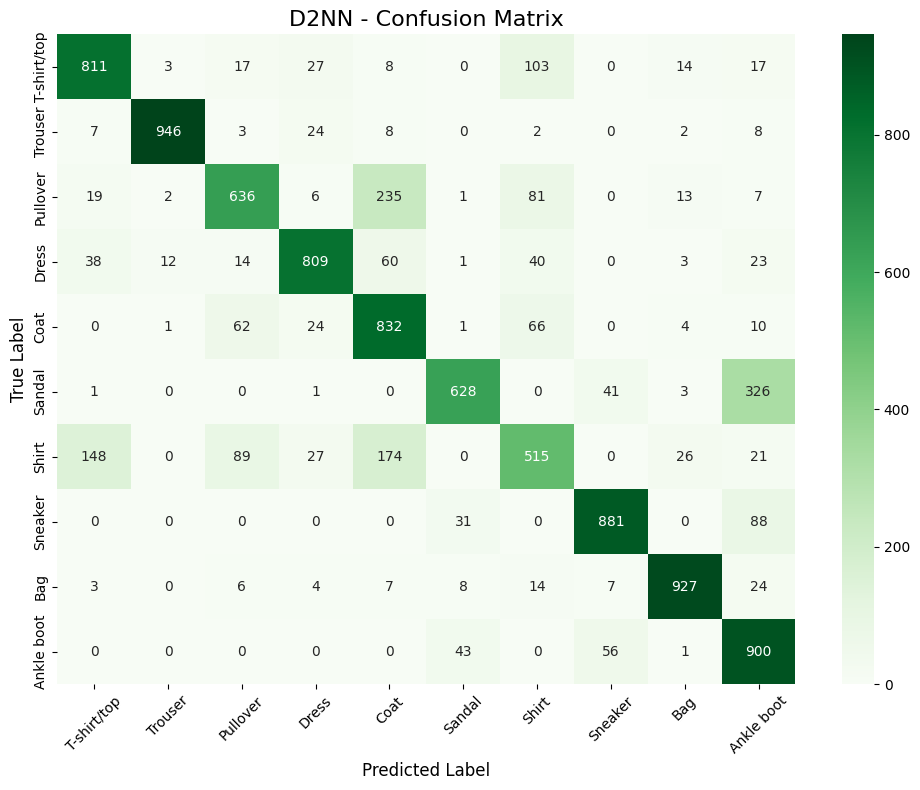

In [15]:
# === Task 4: Model Evaluation (D2NN) ===
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Starting D2NN model prediction and evaluation...")

y_pred_probs_d2nn = d2nn_model.predict(X_test_cnn)
y_pred_d2nn = np.argmax(y_pred_probs_d2nn, axis=1)

acc_d2nn  = accuracy_score(y_test, y_pred_d2nn)
prec_d2nn = precision_score(y_test, y_pred_d2nn, average='macro')
rec_d2nn  = recall_score(y_test, y_pred_d2nn, average='macro')
f1_d2nn   = f1_score(y_test, y_pred_d2nn, average='macro')

print("\n=== D2NN Evaluation Results ===")
print(f"Accuracy:  {acc_d2nn:.4f}")
print(f"Precision: {prec_d2nn:.4f}")
print(f"Recall:    {rec_d2nn:.4f}")
print(f"F1-score:  {f1_d2nn:.4f}")
print("===============================")

cm_d2nn = confusion_matrix(y_test, y_pred_d2nn)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_d2nn, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('D2NN - Confusion Matrix', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Plotting the performance comparison chart for the three models...


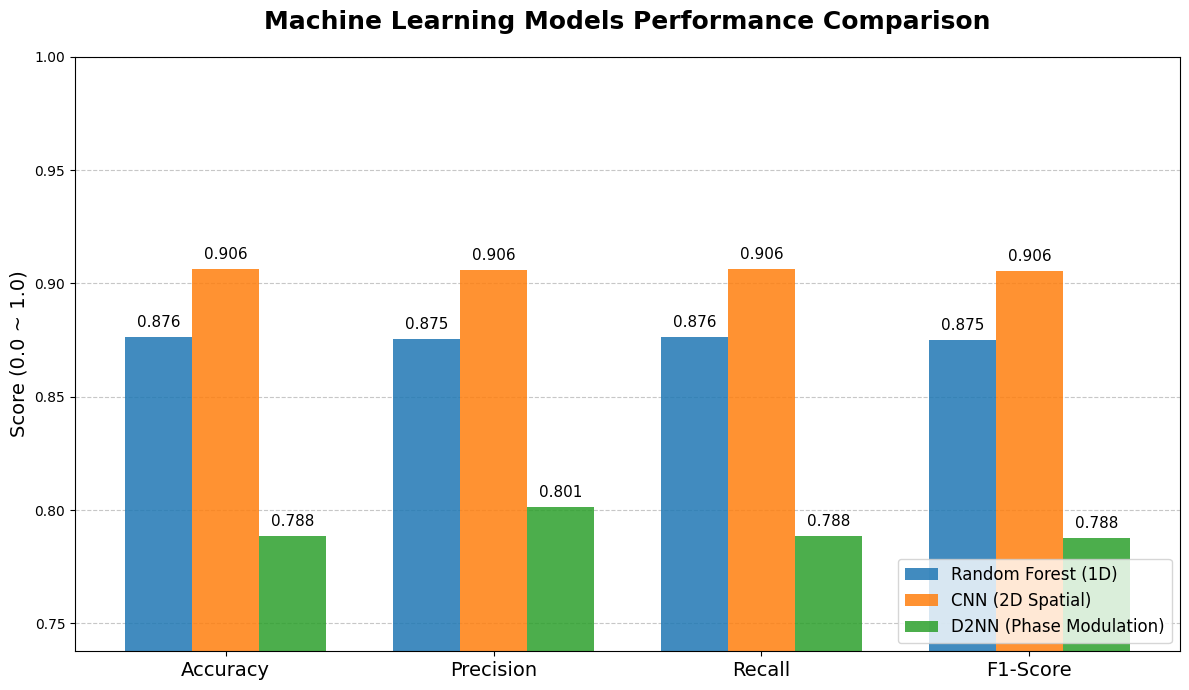

In [16]:
# === Task 4 & 7: Comprehensive Model Comparison Visualization ===
import matplotlib.pyplot as plt
import numpy as np

print("Plotting the performance comparison chart for the three models...")

# Define the names of the four metrics to compare
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Organize the data for the three models (these variables were calculated in previous cells)
rf_scores = [acc_rf, prec_rf, rec_rf, f1_rf]
cnn_scores = [acc_cnn, prec_cnn, rec_cnn, f1_cnn]
d2nn_scores = [acc_d2nn, prec_d2nn, rec_d2nn, f1_d2nn]

# Set the X-axis positions and width for the bar chart
x = np.arange(len(metrics))  
width = 0.25  

fig, ax = plt.subplots(figsize=(12, 7))

# Plot the bar chart (colors correspond to the colormaps used in earlier confusion matrices)
rects1 = ax.bar(x - width, rf_scores, width, label='Random Forest (1D)', color='#1f77b4', alpha=0.85)
rects2 = ax.bar(x, cnn_scores, width, label='CNN (2D Spatial)', color='#ff7f0e', alpha=0.85)
rects3 = ax.bar(x + width, d2nn_scores, width, label='D2NN (Phase Modulation)', color='#2ca02c', alpha=0.85)

# Add labels, title, and custom X-axis ticks
ax.set_ylabel('Score (0.0 ~ 1.0)', fontsize=14)
ax.set_title('Machine Learning Models Performance Comparison', fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=14)
ax.legend(loc='lower right', fontsize=12)

# Set the Y-axis display range. To make differences more obvious, we don't start from 0, but slightly below the lowest score
# Here we take the lowest score among the three models and subtract 0.05 as the Y-axis baseline
min_score = min(min(rf_scores), min(cnn_scores), min(d2nn_scores))
ax.set_ylim(max(0, min_score - 0.05), 1.0) 

# Annotate specific values on top of each bar (rounded to 3 decimal places)
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # Vertical offset of 5 units
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

# Add horizontal grid lines to make the comparison clearer
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

fig.tight_layout()
plt.show()